In [1]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

plt.rc('font', size=7.5, weight='normal')
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [2]:
def MILP_optimization_with_K(
    para_theta_i_p,
    para_theta_i_n,
    fixed_cost,
    c_k,
    N=50,
    force_no_ai=False,
    force_K_zero=False,
    print_details=True
):

    EPS = 1e-8  # numerical tolerance

    I = ["MDD", "AD", "PTSD"]

    queue_length = {i: 0.0 for i in I}
    waiting_time = {i: 0.0 for i in I}
    Z = {i: 0.0 for i in I}
    Y = {i: 0.0 for i in I}
    W = {i: 0 for i in I}
    bar_P_i = {i: 0.0 for i in I}

    # =========================
    # Parameters
    # =========================
    lambda_i = {"MDD": 81, "AD": 57, "PTSD": 113}
    b_i = {"MDD": 12000, "AD": 9000, "PTSD": 13000}
    f_i = {i: fixed_cost for i in I}
    h_i = {"MDD": 324.12, "AD": 196.13, "PTSD": 377.50}
    drop_i = b_i.copy()

    beta = 1 - 0.18
    mu_i = {
        "MDD": beta / 13.5 * 40,
        "AD": beta / 13.5 * 40,
        "PTSD": beta / 12 * 40,
    }

    gamma_i = {i: 0.0067 for i in I}
    theta_i = {i: 0.04 for i in I}
    theta_i_p = {i: para_theta_i_p for i in I}
    theta_i_n = {i: para_theta_i_n for i in I}
    theta_i_w = {i: theta_i_p[i] + theta_i_n[i] for i in I}

    alpha_i = {"MDD": 240, "AD": 180, "PTSD": 260}
    alpha_i_n = {"MDD": 120, "AD": 90, "PTSD": 130}
    h_i_w = {
        "MDD": h_i["MDD"] * 0.1,
        "AD": h_i["AD"] * 0.1,
        "PTSD": h_i["PTSD"] * 0.1,
    }

    c_i = {i: h_i[i] + alpha_i[i] * theta_i[i] for i in I}
    c_i_w = {
        i: h_i_w[i] + alpha_i_n[i] * theta_i_n[i] - b_i[i] * theta_i_p[i] + 1
        for i in I
    }

    r_i = {i: b_i[i] * mu_i[i] - gamma_i[i] * drop_i[i] for i in I}

    P_i = {
        i: (r_i[i] * theta_i[i] + c_i[i] * (mu_i[i] + gamma_i[i])) / theta_i[i]
        for i in I
    }
    P_i_w = {
        i: (r_i[i] * theta_i_w[i] + c_i_w[i] * (mu_i[i] + gamma_i[i])) / theta_i_w[i]
        for i in I
    }

    z_max = {i: lambda_i[i] / (mu_i[i] + gamma_i[i]) for i in I}

    # =========================
    # Model
    # =========================
    model = gp.Model("MentalHealth_MILP_with_K")
    model.setParam("OutputFlag", 0)

    z = model.addVars(I, lb=0.0, ub=z_max, vtype=GRB.CONTINUOUS)
    y = model.addVars(I, lb=0.0, vtype=GRB.CONTINUOUS)
    w = model.addVars(I, vtype=GRB.BINARY)
    K = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS)

    if force_no_ai:
        for i in I:
            model.addConstr(w[i] == 0)

    if force_K_zero:
        model.addConstr(K == 0)

    for i in I:
        model.addConstr(y[i] <= z_max[i] * w[i])
        model.addConstr(y[i] >= z[i] - z_max[i] * (1 - w[i]))
        model.addConstr(y[i] <= z[i])

    model.addConstr(gp.quicksum(z[i] for i in I) <= N + K)

    model.setObjective(
        gp.quicksum(
            (P_i[i] * (z[i] - y[i]) + P_i_w[i] * y[i])
            - lambda_i[i]
            * ((c_i[i] / theta_i[i]) * (1 - w[i]) + (c_i_w[i] / theta_i_w[i]) * w[i])
            - f_i[i] * w[i]
            for i in I
        )
        - c_k * K,
        GRB.MAXIMIZE,
    )

    model.optimize()

    # =========================
    # Post-processing (SAFE)
    # =========================
    if model.status == GRB.OPTIMAL:
        for i in I:
            Z[i] = z[i].X
            Y[i] = y[i].X
            W[i] = int(round(w[i].X))
            bar_P_i[i] = P_i[i] * (1 - W[i]) + P_i_w[i] * W[i]

            q = (
                ((1 - W[i]) / theta_i[i] + W[i] / theta_i_w[i]) * lambda_i[i]
                - (mu_i[i] + gamma_i[i])
                * ((1 - W[i]) / theta_i[i] + W[i] / theta_i_w[i])
                * Z[i]
            )

            queue_length[i] = max(0.0, q if abs(q) > EPS else 0.0)
            waiting_time[i] = (
                queue_length[i] / lambda_i[i] if queue_length[i] > EPS else 0.0
            )

        opt_obj = model.ObjVal
        K_val = max(0.0, K.X)

    else:
        opt_obj = None
        K_val = None

    return Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, K_val, opt_obj


In [3]:
Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, K_val, opt_obj= MILP_optimization_with_K(
            para_theta_i_p=0.06, 
            para_theta_i_n=0.0005,
            force_no_ai=False, 
            force_K_zero=False,
            #holding_cost_change=0.01, 
            fixed_cost=640, 
            c_k=2000, 
            print_details=False, 
            N=50
        )
print('z: ', Z)
print('w: ', W)
print('queue_length: ', queue_length)
print('waiting_time: ', waiting_time)
print('P_i: ', P_i)
print('P_i_w: ', P_i_w)
print('bar_P_i: ', bar_P_i)
print('K (Recruited Capacity):', K_val)
print('opt_obj:', opt_obj)



Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-23
z:  {'MDD': 8.759625795306633, 'AD': 0.0, 'PTSD': 41.24037420469337}
w:  {'MDD': 1, 'AD': 1, 'PTSD': 0}
queue_length:  {'MDD': 986.0936219905198, 'AD': 942.1487603305786, 'PTSD': 0.0}
waiting_time:  {'MDD': 12.173995333216293, 'AD': 16.528925619834713, 'PTSD': 0.0}
P_i:  {'MDD': 49401.45365555556, 'AD': 34190.83925648149, 'PTSD': 62017.70658333335}
P_i_w:  {'MDD': 1428.7339362105877, 'AD': 892.5104268135944, 'PTSD': 1878.1076115702558}
bar_P_i:  {'MDD': 1428.7339362105877, 'AD': 892.5104268135944, 'PTSD': 62017.70658333335}
K (Recruited Capacity): 0.0
opt_obj: 2881501.7130260505


In [4]:
Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, K_val, opt_obj= MILP_optimization_with_K(
            para_theta_i_p=0.06, 
            para_theta_i_n=0.0005,
            force_no_ai=True, 
            force_K_zero=False,
            #holding_cost_change=0.01, 
            fixed_cost=640, 
            c_k=2000, 
            print_details=False, 
            N=50
        )
print('z: ', Z)
print('w: ', W)
print('queue_length: ', queue_length)
print('waiting_time: ', waiting_time)
print('P_i: ', P_i)
print('P_i_w: ', P_i_w)
print('bar_P_i: ', bar_P_i)
print('K (Recruited Capacity):', K_val)
print('opt_obj:', opt_obj)

z:  {'MDD': 33.24673271420731, 'AD': 23.395848947034775, 'PTSD': 41.24037420469337}
w:  {'MDD': 0, 'AD': 0, 'PTSD': 0}
queue_length:  {'MDD': 0.0, 'AD': 0.0, 'PTSD': 0.0}
waiting_time:  {'MDD': 0.0, 'AD': 0.0, 'PTSD': 0.0}
P_i:  {'MDD': 49401.45365555556, 'AD': 34190.83925648149, 'PTSD': 62017.70658333335}
P_i_w:  {'MDD': 1428.7339362105877, 'AD': 892.5104268135944, 'PTSD': 1878.1076115702558}
bar_P_i:  {'MDD': 49401.45365555556, 'AD': 34190.83925648149, 'PTSD': 62017.70658333335}
K (Recruited Capacity): 47.88295578956604
opt_obj: 2842882.4012309536


In [5]:
def MILP_optimization(para_theta_i_p, 
                      para_theta_i_n, 
                      #holding_cost_change, 
                      fixed_cost,
                      force_no_ai=False, 
                      server_capacity=50,
                      print_details=True):

    queue_length = {"MDD": 0, "AD": 0, "PTSD": 0}
    waiting_time = {"MDD": 0, "AD": 0, "PTSD": 0}
    Z = {"MDD": 0, "AD": 0, "PTSD": 0}
    Y = {"MDD": 0, "AD": 0, "PTSD": 0}
    W = {"MDD": 0, "AD": 0, "PTSD": 0}
    
    I = ["MDD", "AD", "PTSD"]

    lambda_i = {"MDD": 81, "AD": 57, "PTSD": 113} 
    b_i = {"MDD": 12_000, "AD": 9_000, "PTSD": 13_000}
    f_i = {i: fixed_cost for i in I}
    h_i = {"MDD": 324.12, "AD": 196.13, "PTSD": 377.50}
    drop_i = {i: b_i[i] for i in I}

    beta = 1 - 0.18
    mu_i = {
        "MDD": beta / 13.5 * 40,
        "AD": beta / 13.5 * 40,
        "PTSD": beta / 12 * 40,
    }

    gamma_i = {i: 0.0067 for i in I}
    theta_i = {i: 0.04 for i in I}
    theta_i_p = {i: para_theta_i_p for i in I}
    theta_i_n = {i: para_theta_i_n for i in I}
    theta_i_w = {i: theta_i_p[i] + theta_i_n[i] for i in I}


    alpha_i = {"MDD": 240, "AD": 180, "PTSD": 260}
    alpha_i_n = {"MDD": 120, "AD": 90, "PTSD": 130}
    a_i = {i: 1 for i in I}
    h_i_w = {
    "MDD": h_i["MDD"] * 0.1,
    "AD": h_i["AD"] * 0.1,
    "PTSD": h_i["PTSD"] * 0.1
 }

    c_i = {i: h_i[i] + alpha_i[i] * theta_i[i] for i in I}
    c_i_w = {i: h_i_w[i] + alpha_i_n[i] * theta_i_n[i] - b_i[i] * theta_i_p[i] + a_i[i] for i in I}

    r_i = {i: b_i[i] * mu_i[i] - gamma_i[i] * drop_i[i] for i in I}

    P_i = {
        i: (r_i[i] * theta_i[i] + c_i[i] * (mu_i[i] + gamma_i[i])) / theta_i[i]
        for i in I
    }

    P_i_w = {
        i: (r_i[i] * theta_i_w[i] + c_i_w[i] * (mu_i[i] + gamma_i[i])) / theta_i_w[i]
        for i in I
    }

    z_max = {i: lambda_i[i] / (mu_i[i] + gamma_i[i]) for i in I}

    model = gp.Model("MentalHealth_MILP")
    model.setParam('OutputFlag', 0)
    
    z = model.addVars(I, name="z", lb=0.0, ub=z_max, vtype=GRB.CONTINUOUS)
    y = model.addVars(I, name="y", lb=0.0, vtype=GRB.CONTINUOUS)
    w = model.addVars(I, name="w", vtype=GRB.BINARY)

    if force_no_ai:
        for i in I:
            model.addConstr(w[i] == 0)

    for i in I:
        model.addConstr(y[i] <= z_max[i] * w[i])
        model.addConstr(y[i] >= z[i] - z_max[i] * (1 - w[i]))
        model.addConstr(y[i] <= z[i])

    model.addConstr(gp.quicksum(z[i] for i in I) <= server_capacity)

    model.setObjective(
        gp.quicksum(
            (P_i[i] * (z[i] - y[i]) + P_i_w[i] * y[i]) -
            lambda_i[i] * ((c_i[i] / theta_i[i]) * (1 - w[i]) + (c_i_w[i] / theta_i_w[i]) * w[i]) -
            f_i[i] * w[i]
            for i in I
        ),
        GRB.MAXIMIZE
    )

    model.optimize()

    bar_P_i = {}

    if model.status == GRB.OPTIMAL:
        opt_obj = model.ObjVal
        for i in I:
            queue_length[i] = ((1 - w[i].X) / theta_i[i] + w[i].X / theta_i_w[i]) * lambda_i[i] - \
                              (mu_i[i] + gamma_i[i]) * ((1 - w[i].X) / theta_i[i] + w[i].X / theta_i_w[i]) * z[i].X
            waiting_time[i] = queue_length[i] / lambda_i[i]
            Z[i] = z[i].X
            Y[i] = y[i].X
            W[i] = int(w[i].X)
            bar_P_i[i] = P_i[i] * (1 - w[i].X) + P_i_w[i] * w[i].X
        if print_details:
            print("✅ Optimal solution found. Objective value: {:.2f}".format(opt_obj))
    else:
        opt_obj = None
        if print_details:
            print("❌ No optimal solution found.")

    return Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, opt_obj


In [6]:
z, w, q, waiting, _, _, _, N_val, _ = MILP_optimization_with_K(
            para_theta_i_p=0.06, 
            para_theta_i_n=0.0005,
            force_no_ai=False, 
            force_K_zero=False,
            #holding_cost_change=0.01, 
            fixed_cost=640, 
            c_k=2000, 
            print_details=False, 
            N=50
        )

In [7]:
q, waiting

({'MDD': 986.0936219905198, 'AD': 942.1487603305786, 'PTSD': 0.0},
 {'MDD': 12.173995333216293, 'AD': 16.528925619834713, 'PTSD': 0.0})

["{'MDD': 0, 'AD': 0, 'PTSD': 0}True", "{'MDD': 1, 'AD': 1, 'PTSD': 0}True", "{'MDD': 1, 'AD': 1, 'PTSD': 1}False", "{'MDD': 0, 'AD': 1, 'PTSD': 0}True"]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
["{'MDD': 0, 'AD': 0, 'PTSD': 0}True", "{'MDD': 0, 'AD': 1, 'PTSD': 0}True", "{'MDD': 1, 'AD': 1, 'PTSD': 0}False"]
[[4 4 4 ... 4 4 4]
 [4 4 4 ... 4 4 4]
 [4 4 4 ... 4 4 4]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
["{'MDD': 0, 'AD': 0, 'PTSD': 0}True", "{'MDD': 0, 'AD': 1, 'PTSD': 0}False"]
[[5 5 5 ... 5 5 5]
 [5 5 5 ... 5 5 5]
 [5 5 5 ... 5 5 5]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
Total runtime: 20.83 seconds


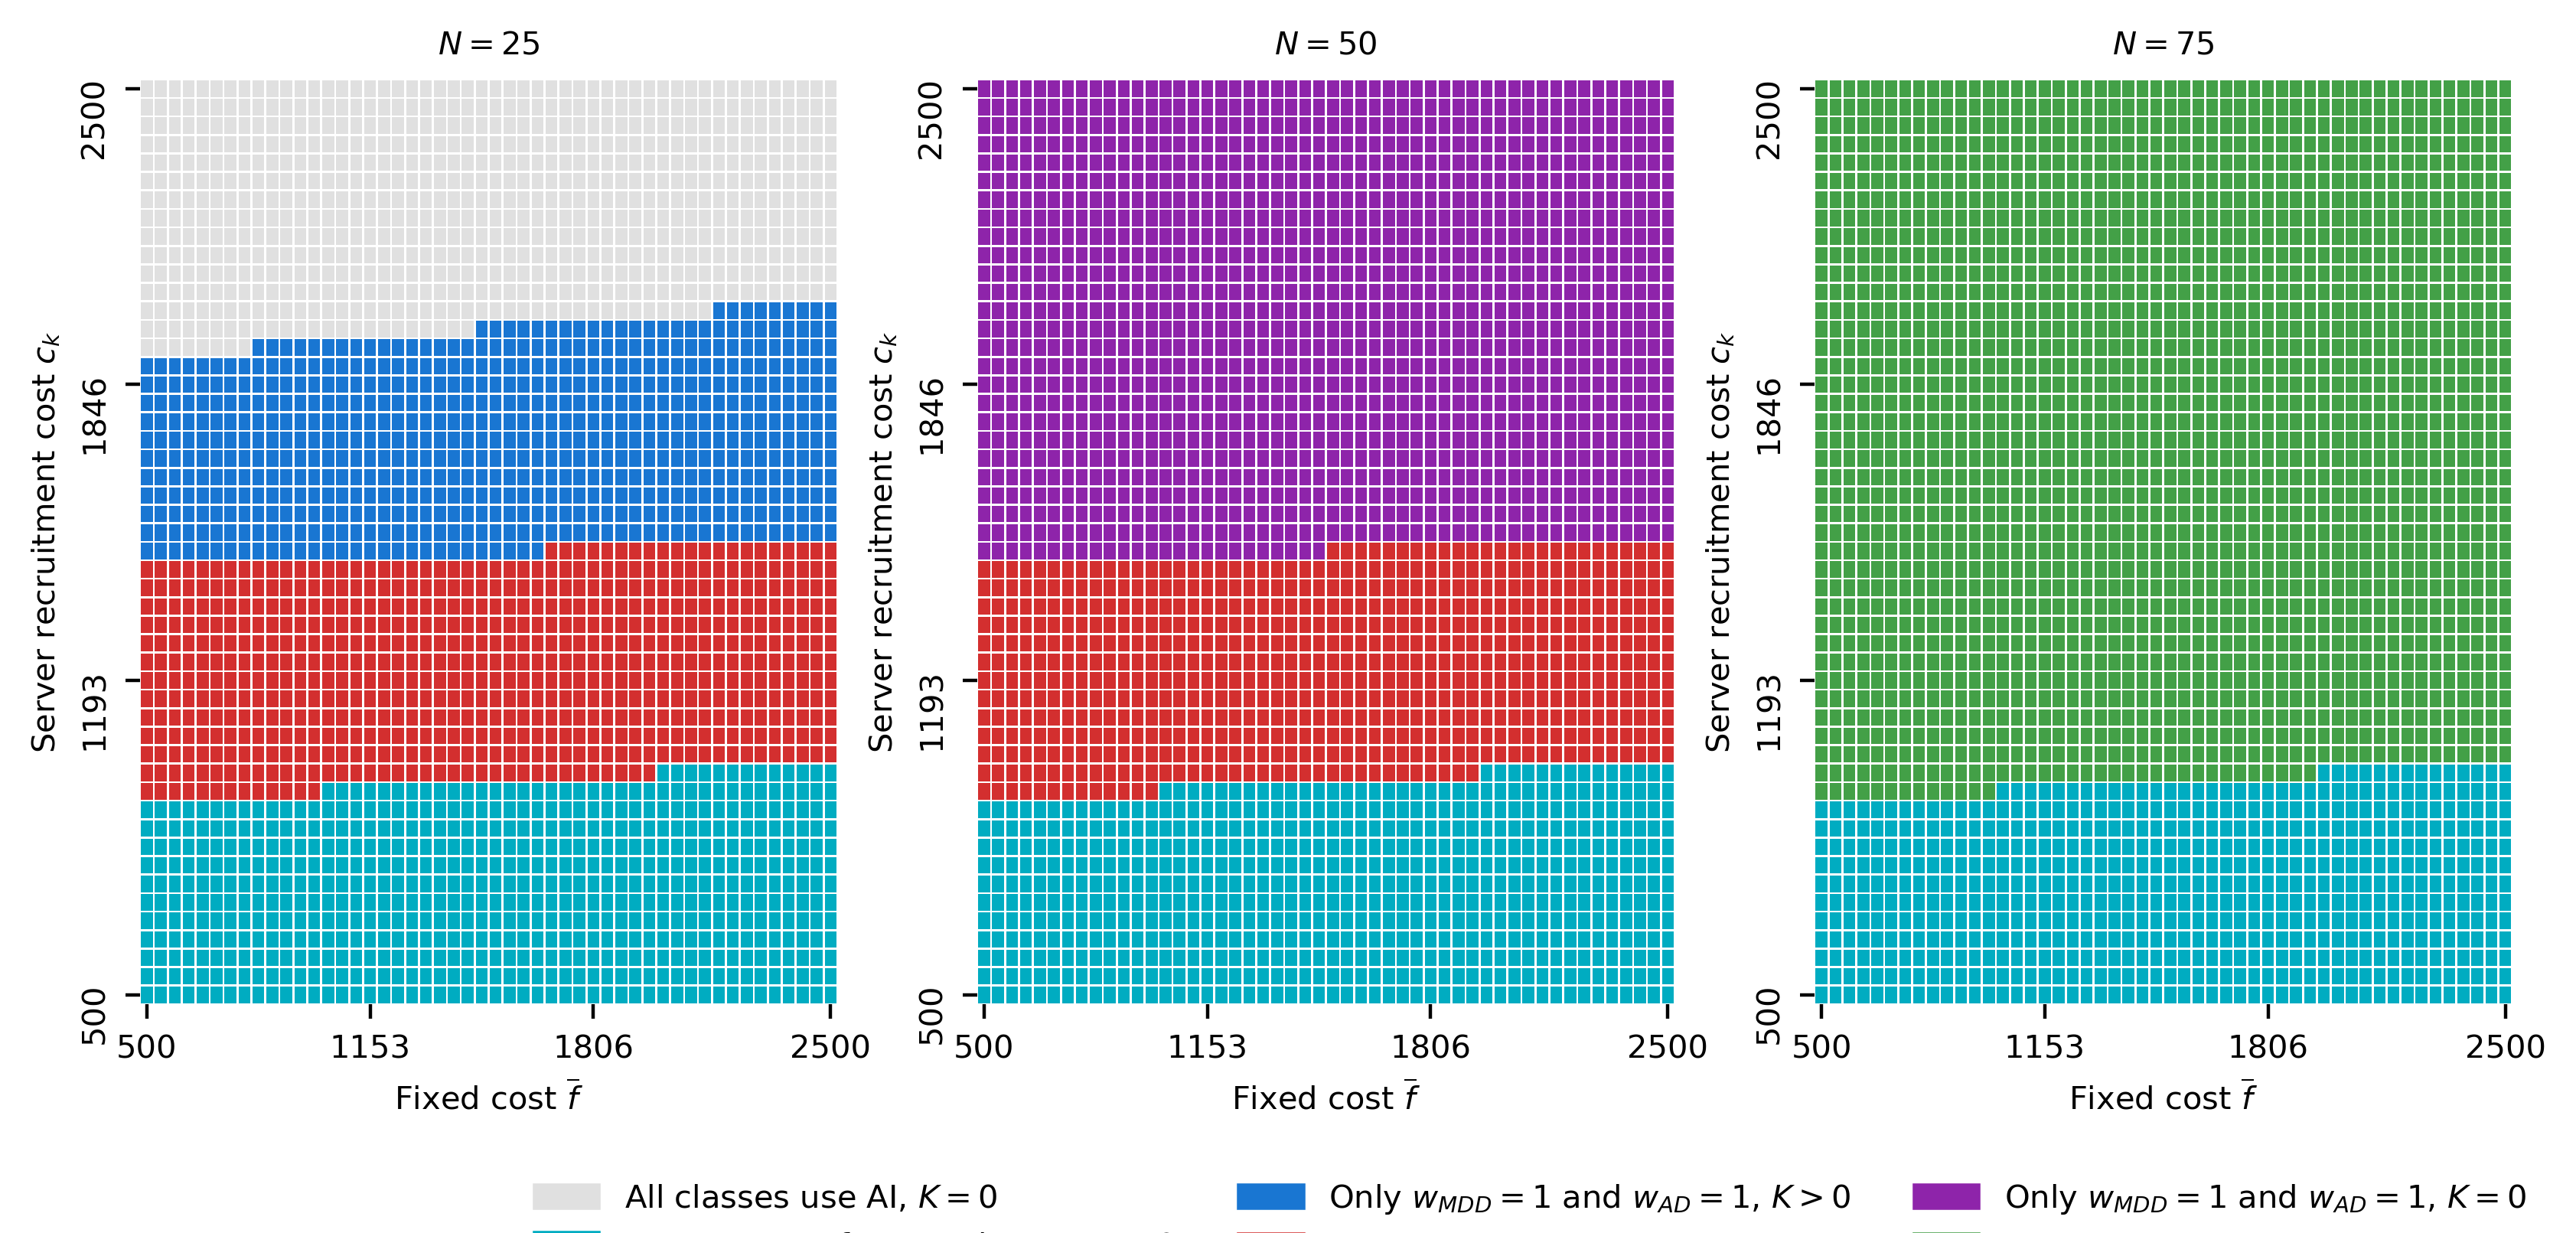

In [8]:
import time

start_time = time.perf_counter()

fig = plt.figure(figsize=(10, 4), dpi=400)

plt.subplot(131)

classes = ["MDD", "AD", "PTSD"]
fixed_cost_vals = np.linspace(500 ,2500, 50, dtype=int)  
ck_vals = np.linspace(500, 2500, 50, dtype=int)          
cat_matrix = np.zeros((len(ck_vals), len(fixed_cost_vals)), dtype=int)
LIST = []
for i, ck in enumerate(ck_vals):
    for j, fc in enumerate(fixed_cost_vals):
        z, w, queue_length, waiting_time, P_i, P_i_w, bar_P_i, K_val, opt_obj = MILP_optimization_with_K(
            para_theta_i_p=0.06,
            para_theta_i_n=0.0005,
            force_no_ai=False,       
            force_K_zero=False,
            #holding_cost_change=0.01,
            fixed_cost=fc,
            c_k=ck,
            N=25,
            print_details=False
        )
        LIST.append(str(w)+str(K_val>0))
        kpos = K_val>0
        if w['MDD'] == int(0) and w['AD'] == int(0) and w['PTSD'] == int(0) and kpos:
            cat_matrix[i, j] = 1
        if w['MDD'] == int(1) and w['AD'] == int(1) and w['PTSD'] == int(0) and kpos:
            cat_matrix[i, j] = 2
        if w['MDD'] == int(1) and w['AD'] == int(1) and w['PTSD'] == int(1) and kpos == False:
            cat_matrix[i, j] = 0
        elif w['MDD'] == int(0) and w['AD'] == int(1) and w['PTSD'] == int(0) and kpos:
            cat_matrix[i, j] = 3
      
set_list = list(set(LIST))
print(set_list)

#["{'MDD': 0, 'AD': 0, 'PTSD': 0}True", "{'MDD': 1, 'AD': 1, 'PTSD': 0}True", 
 #"{'MDD': 1, 'AD': 1, 'PTSD': 1}False", "{'MDD': 0, 'AD': 1, 'PTSD': 0}True"]

color_labels = {
    0: r"All classes use AI, $K=0$",
    1: r"Never use AI for any classes, $K>0$",
    2: r"Only $w_{MDD} = 1$ and $w_{AD} = 1$, $K>0$",
    3: r"Only $w_{AD} = 1$, $K>0$" 
   
    
}
colors = [
    "#e0e0e0",  # 0: all "All classes use AI, K=0  
    "#00acc1",  # 1: Never use AI for any classes, K>0
    "#1976d2",  # 2: MDD AD use AI k>0 
    "#d32f2f",  # 3:Only AD ,K>0
    
    
]
data = np.flipud(cat_matrix)
print(data)
pd.DataFrame(data,index=ck_vals,columns=fixed_cost_vals).to_excel('11.xlsx')
cmap = ListedColormap(colors)
sns.heatmap(
        data,
        cmap=cmap,
        annot=False,
        cbar=False, vmin=0, vmax=3,
        linewidths=0.3, 
        linecolor='white')
num_xticks = 4
xtick_pos = np.linspace(0, len(fixed_cost_vals)-1, num_xticks, dtype=int)
xtick_labels = [f"{fixed_cost_vals[i]}" for i in xtick_pos]

num_yticks = 4
ytick_pos = np.linspace(0, len(ck_vals)-1, num_yticks, dtype=int)
ytick_labels = [f"{ck_vals[::-1][i]}" for i in ytick_pos]

plt.xticks(xtick_pos + 0.5, xtick_labels, rotation=0)
plt.yticks(ytick_pos + 0.5, ytick_labels, rotation=90)

plt.ylabel(r'Server recruitment cost $c_k$')
plt.xlabel(r'Fixed cost $\overline{{f}}$')
plt.title(r'$N=25$',fontsize = 7.5)

plt.subplot(132)

classes = ["MDD", "AD", "PTSD"]
fixed_cost_vals = np.linspace(500 ,2500, 50, dtype=int)  
ck_vals = np.linspace(500, 2500, 50, dtype=int)         
cat_matrix = np.zeros((len(ck_vals), len(fixed_cost_vals)), dtype=int)
LIST = []
for i, ck in enumerate(ck_vals):
    for j, fc in enumerate(fixed_cost_vals):
        z, w, queue_length, waiting_time, P_i, P_i_w, bar_P_i, K_val, opt_obj = MILP_optimization_with_K(
            para_theta_i_p=0.06,
            para_theta_i_n=0.0005,
            force_no_ai=False,        
            force_K_zero=False,
            #holding_cost_change=0.01,
            fixed_cost=fc,
            c_k=ck,
            N=50,
            print_details=False
        )
        LIST.append(str(w)+str(K_val>0))
        kpos = K_val>0
        if w['MDD'] == int(0) and w['AD'] == int(0) and w['PTSD'] == int(0) and kpos:
            cat_matrix[i, j] = 1
        if w['MDD'] == int(1) and w['AD'] == int(1) and w['PTSD'] == int(0) and kpos == False:
            cat_matrix[i, j] = 4
        if w['MDD'] == int(0) and w['AD'] == int(1) and w['PTSD'] == int(0) and kpos:
            cat_matrix[i, j] = 3

set_list = list(set(LIST))
print(set_list)
#["{'MDD': 0, 'AD': 0, 'PTSD': 0}True", "{'MDD': 1, 'AD': 1, 'PTSD': 0}False", "{'MDD': 0, 'AD': 1, 'PTSD': 0}True"]

color_labels = {    
    
    1: r"Never use AI for any classes, $K>0$",
    3: r"Only $w_{AD} = 1$, $K>0$",
    4: r"Only $w_{MDD} = 1$ and $w_{AD} = 1$, $K=0$"
     

}
colors = [
    
    "#00acc1",  # 1: Never use AI for any classes, K>0
    "#d32f2f",  # 3:Only AD，K>0
    "#8e24aa",  # 4: MDD AD use AI k=0
]
data = np.flipud(cat_matrix)
print(data)
pd.DataFrame(data,index=ck_vals,columns=fixed_cost_vals).to_excel('22.xlsx')
cmap = ListedColormap(colors)
sns.heatmap(
        data,
        cmap=cmap,
        annot=False,
        cbar=False, vmin=0, vmax=5,
        linewidths=0.3, 
        linecolor='white')
num_xticks = 4
xtick_pos = np.linspace(0, len(fixed_cost_vals)-1, num_xticks, dtype=int)
xtick_labels = [f"{fixed_cost_vals[i]}" for i in xtick_pos]

num_yticks = 4
ytick_pos = np.linspace(0, len(ck_vals)-1, num_yticks, dtype=int)
ytick_labels = [f"{ck_vals[::-1][i]}" for i in ytick_pos]

plt.xticks(xtick_pos + 0.5, xtick_labels, rotation=0)
plt.yticks(ytick_pos + 0.5, ytick_labels, rotation=90)

plt.ylabel(r'Server recruitment cost $c_k$')
plt.xlabel(r'Fixed cost $\overline{{f}}$')
plt.title(r'$N=50$',fontsize = 7.5)

plt.subplot(133)
classes = ["MDD", "AD", "PTSD"]
fixed_cost_vals = np.linspace(500 ,2500, 50, dtype=int)  
ck_vals = np.linspace(500, 2500, 50, dtype=int)   
cat_matrix = np.zeros((len(ck_vals), len(fixed_cost_vals)), dtype=int)
LIST = []
for i, ck in enumerate(ck_vals):
    for j, fc in enumerate(fixed_cost_vals):
        z, w, queue_length, waiting_time, P_i, P_i_w, bar_P_i, K_val, opt_obj = MILP_optimization_with_K(
            para_theta_i_p=0.06,
            para_theta_i_n=0.0005,
            force_no_ai=False,         
            force_K_zero=False,
            #holding_cost_change=0.01,
            fixed_cost=fc,
            c_k=ck,
            N=75,
            print_details=False
        )
        LIST.append(str(w)+str(K_val>0))
        kpos = K_val>0
        if w['MDD'] == int(0) and w['AD'] == int(0) and w['PTSD'] == int(0) and kpos:
            cat_matrix[i, j] = 1
        if w['MDD'] == int(0) and w['AD'] == int(1) and w['PTSD'] == int(0) and kpos == False:
            cat_matrix[i, j] = 5
        
set_list = list(set(LIST))
print(set_list)
#["{'MDD': 0, 'AD': 0, 'PTSD': 0}True", "{'MDD': 0, 'AD': 1, 'PTSD': 0}False"]

color_labels = {
     1: r"Never use AI for any classes, $K>0$",
     5: r"Only $w_{AD} = 1$, $K=0$"
  
}

colors = [
    "#00acc1",  # 1: Never use AI for any classes, K>0
    "#43a047",  # 5: Only AD , k=0
   
      
]

data = np.flipud(cat_matrix)
print(data)
pd.DataFrame(data,index=ck_vals,columns=fixed_cost_vals).to_excel('33.xlsx')
cmap = ListedColormap(colors)
sns.heatmap(
        data,
        cmap=cmap,
        annot=False,
        cbar=False, vmin=0, vmax=5,
        linewidths=0.3, 
        linecolor='white')
num_xticks = 4
xtick_pos = np.linspace(0, len(fixed_cost_vals)-1, num_xticks, dtype=int)
xtick_labels = [f"{fixed_cost_vals[i]}" for i in xtick_pos]

num_yticks = 4
ytick_pos = np.linspace(0, len(ck_vals)-1, num_yticks, dtype=int)
ytick_labels = [f"{ck_vals[::-1][i]}" for i in ytick_pos]

plt.xticks(xtick_pos + 0.5, xtick_labels, rotation=0)
plt.yticks(ytick_pos + 0.5, ytick_labels, rotation=90)

plt.ylabel(r'Server recruitment cost $c_k$')
plt.xlabel(r'Fixed cost $\overline{{f}}$')
plt.title(r'$N=75$',fontsize = 7.5)

color_labels = {
    0: r"All classes use AI, $K=0$",
    1: r"Never use AI for any classes, $K>0$",
    2: r"Only $w_{MDD} = 1$ and $w_{AD} = 1$, $K>0$",
    3: r"Only $w_{AD} = 1$, $K>0$" ,
    4: r"Only $w_{MDD} = 1$ and $w_{AD} = 1$, $K=0$",
    5: r"Only $w_{AD} = 1$, $K=0$"
}
colors = [
    "#e0e0e0",  # 0: all "All classes use AI, K=0  
    "#00acc1",  # 1: Never use AI for any classes, K>0
    "#1976d2",  # 2: MDD AD use AI k>0 
    "#d32f2f",  # 3:Only AD，K>0
    "#8e24aa",  # 4: MDD AD use AI k=0 
    "#43a047",  # 5: Only AD ， k=0
]

legend_patches = [mpatches.Patch(color=colors[val], label=label) for val, label in color_labels.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, frameon=False, bbox_to_anchor = (0.5, -0.05))

plt.savefig('20.eps', dpi=500, bbox_inches='tight')
plt.savefig('20.pdf', dpi=500, bbox_inches='tight')

end_time = time.perf_counter()
print(f"Total runtime: {end_time - start_time:.2f} seconds")


plt.show()




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

Total runtime: 1.28 seconds


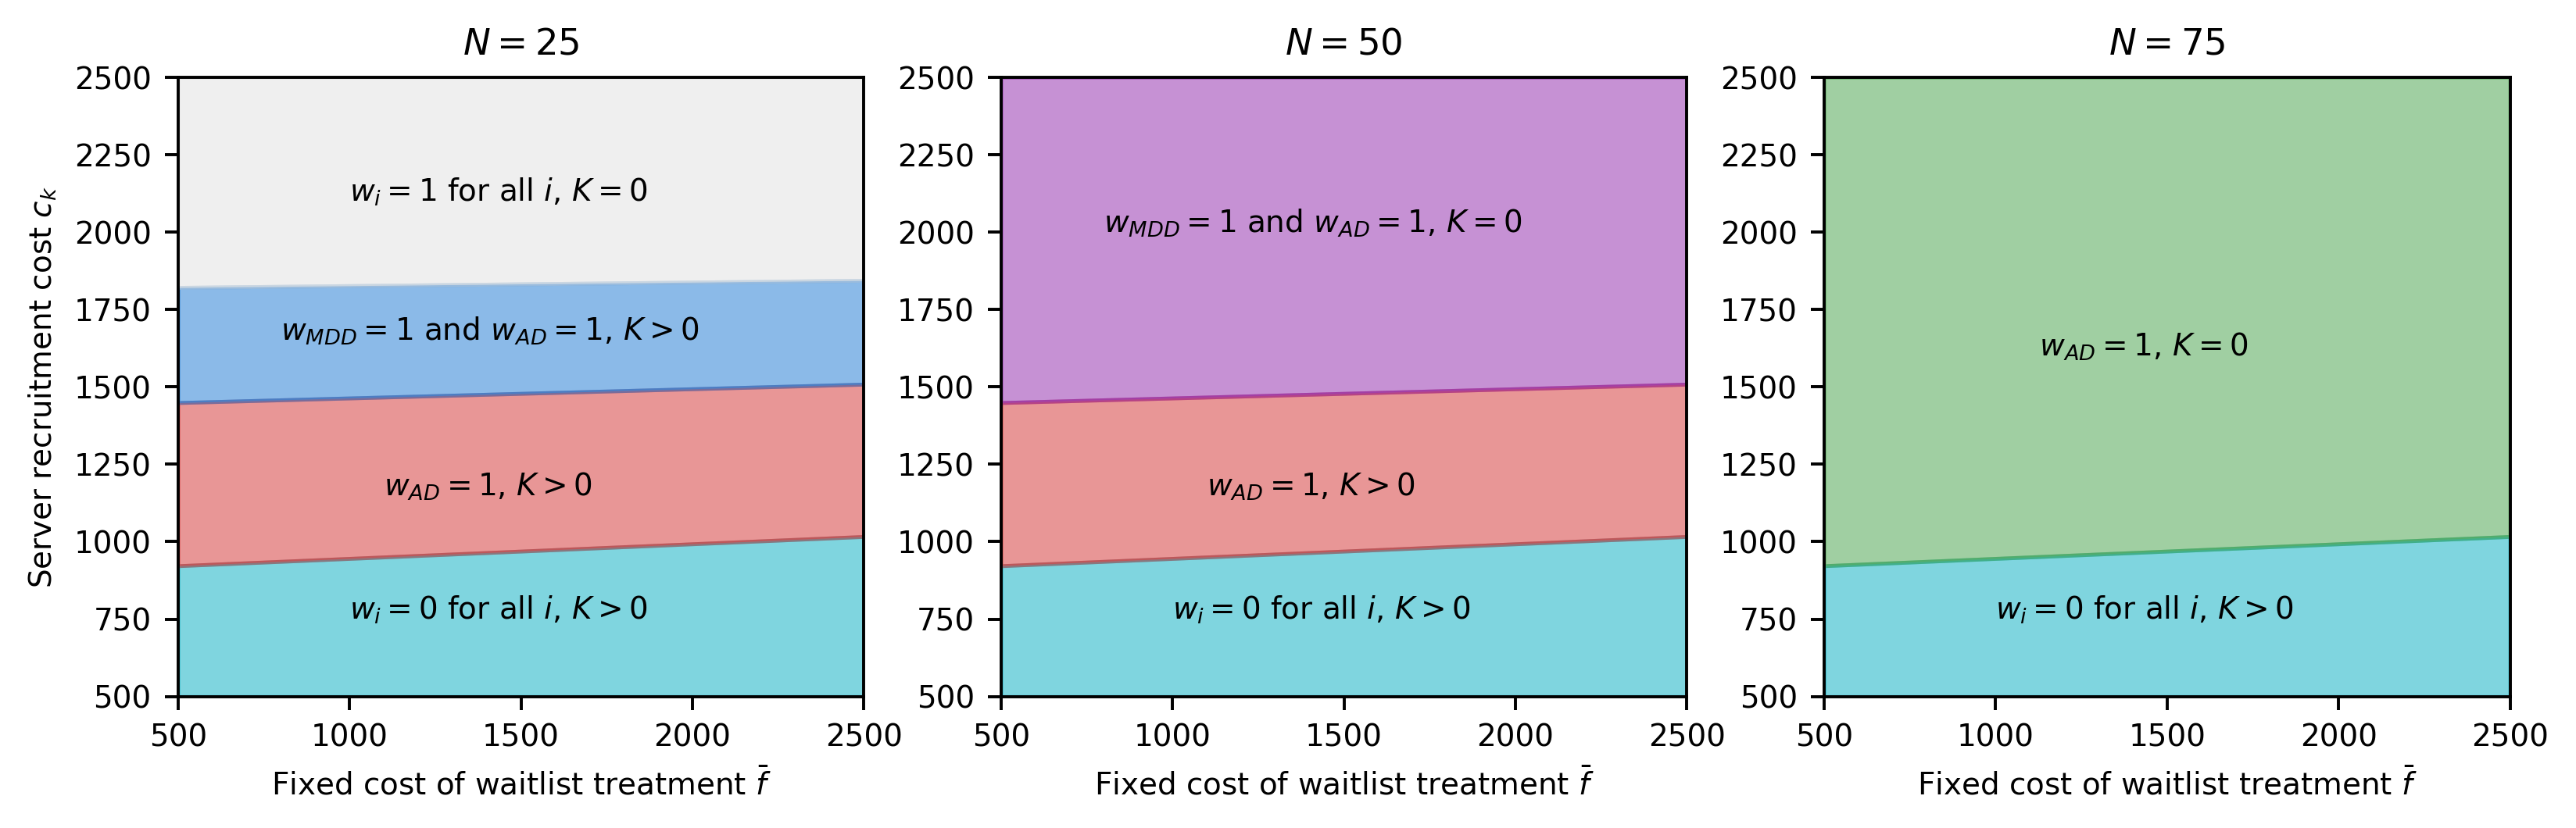

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

start_time = time.perf_counter()

fig = plt.figure(figsize=(11, 3), dpi=350)
plt.rc('font', size=8, weight='normal')

# 11
b13 = [922.244469206903, 1016.700869865414]     # 1 -> 3
b32 = [1449.2002145234867, 1508.6945113247548] # 3 -> 2
b20 = [1821.1185562439324, 1843.972821695996]  # 2 -> 0

plt.subplot(131)
plt.xlim(500, 2500)
plt.ylim(500, 2500)

plt.fill_between([500,2500], [500,500], b13, color='#00acc1', alpha=0.5)
plt.fill_between([500,2500], b13, b32, color='#d32f2f', alpha=0.5)
plt.fill_between([500,2500], b32, b20, color='#1976d2', alpha=0.5)
plt.fill_between([500,2500], b20, [2500,2500], color='#e0e0e0', alpha=0.5)

plt.title(r'$N=25$')
plt.ylabel(r'Server recruitment cost $c_k$')
plt.xlabel(r'Fixed cost of waitlist treatment $\bar f$')
plt.text(1000,750,r"$w_{i} = 0$ for all $i$, $K>0$")
plt.text(1100,1150, r"$w_{AD} = 1$, $K>0$"  )
plt.text(800,1650, r"$w_{MDD} = 1$ and $w_{AD} = 1$, $K>0$")
plt.text(1000,2100,  r"$w_{i} = 1$ for all $i$, $K=0$")
             
               
# 22
b13 = [922.244469206903, 1016.700869865414]     # 1 -> 3
b34 = [1449.2002145234867, 1508.6945113247548] # 3 -> 4

plt.subplot(132)
plt.xlim(500, 2500)
plt.ylim(500, 2500)

plt.fill_between([500,2500], [500,500], b13, color='#00acc1', alpha=0.5)
plt.fill_between([500,2500], b13, b34, color='#d32f2f', alpha=0.5)
plt.fill_between([500,2500], b34, [2500,2500], color='#8e24aa', alpha=0.5)

plt.title(r'$N=50$')
plt.xlabel(r'Fixed cost of waitlist treatment $\bar f$')

plt.text(1000,750,r"$w_{i} = 0$ for all $i$, $K>0$")
plt.text(1100,1150, r"$w_{AD} = 1$, $K>0$")
plt.text(800,2000, r"$w_{MDD} = 1$ and $w_{AD} = 1$, $K=0$")                 


# 33
b15 = [922.244469206903, 1016.700869865414]  # 1 -> 5

plt.subplot(133)
plt.xlim(500, 2500)
plt.ylim(500, 2500)

plt.fill_between([500,2500], [500,500], b15, color='#00acc1', alpha=0.5)
plt.fill_between([500,2500], b15, [2500,2500], color='#43a047', alpha=0.5)

plt.title(r'$N=75$')
plt.xlabel(r'Fixed cost of waitlist treatment $\bar f$')
plt.text(1000,750,r"$w_{i} = 0$ for all $i$, $K>0$")
plt.text(1100,1600,r" $w_{AD} = 1$, $K=0$")
             
                 
                 
plt.subplots_adjust(hspace=0.3)

plt.savefig('ck_vs_fixed_cost.pdf', bbox_inches='tight') 
plt.savefig('ck_vs_fixed_cost.eps', bbox_inches='tight')

end_time = time.perf_counter()
print(f"Total runtime: {end_time - start_time:.2f} seconds")

plt.show()